# 12. Film Yorumlarında Konu Modelleme

**Kategori:** Doğal Dil İşleme (NLP)  
**Gerçek veri seti:** NLTK Movie Reviews / Pang & Lee Polarity Dataset  
**Veri kaynağı:** [https://www.nltk.org/nltk_data/](https://www.nltk.org/nltk_data/)  
**Amaç:** 2.000 gerçek film yorumunda etiket kullanmadan gizli metin konularını keşfetmek.

Bu notebook; veri yükleme, veri kalitesi kontrolü, keşifsel veri analizi (EDA), görselleştirme,
modelleme, değerlendirme ve çıktı yorumlama adımlarını ayrı ayrı gösterir. Sentetik veya rastgele
üretilmiş gözlem kullanılmamıştır. Rastgelelik yalnızca tekrarlanabilir eğitim/test ayrımı ve
algoritma başlangıcı için `random_state=42` ile kontrol edilmiştir.

In [1]:
from pathlib import Path
import json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
RESULT_DIR = ROOT / "results"
MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)
print("Proje kökü:", ROOT.resolve())

Proje kökü: /workspace/scratch/f0b9bcae3580/Rabia_Yel_21_Gercek_Veri_Projesi


## 1. Metin verisini tanıma

In [2]:
df = pd.read_csv(DATA_DIR / "movie_reviews.csv")
df["word_count"] = df.review.str.split().str.len()
display(df.head(3))
print("Boyut:", df.shape, "| Eksik:", int(df.isna().sum().sum()), "| Tekrar:", df.duplicated().sum())
display(df.groupby("label").word_count.describe().round(1))

Boyut: (2000, 3) | Eksik: 0 | Tekrar: 0


,label,review,word_count
0,negative,"plot : two teen couples go to a church party ,...",825
1,negative,the happy bastard's quick movie review \ndamn ...,278
2,negative,it is movies like these that make a jaded movi...,547


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
negative,1000.0,705.6,296.7,17.0,510.0,668.5,848.2,2181.0
positive,1000.0,787.1,352.8,130.0,543.5,731.5,957.2,2678.0


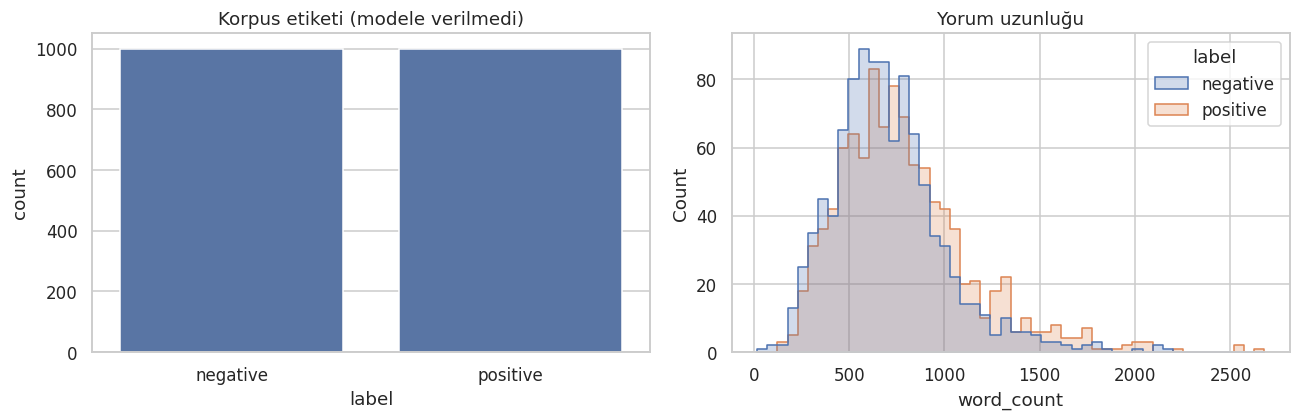

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="label", ax=axes[0]); axes[0].set(title="Korpus etiketi (modele verilmedi)")
sns.histplot(data=df, x="word_count", hue="label", bins=50, element="step", ax=axes[1])
axes[1].set(title="Yorum uzunluğu")
plt.tight_layout(); plt.show()

## 2. TF-IDF + NMF ile denetimsiz konu çıkarımı

In [4]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english", min_df=5, max_df=.80,
                             max_features=6000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df.review)
nmf = NMF(n_components=6, init="nndsvda", random_state=RANDOM_STATE, max_iter=400)
document_topics = nmf.fit_transform(X)
terms = np.array(vectorizer.get_feature_names_out())
topic_terms = pd.DataFrame({
    f"Konu {idx + 1}": terms[weights.argsort()[-10:][::-1]]
    for idx, weights in enumerate(nmf.components_)
})
display(topic_terms)

,Konu 1,Konu 2,Konu 3,Konu 4,Konu 5,Konu 6
0,movie,alien,life,jackie,scream,star wars
1,bad,aliens,story,chan,horror,wars
2,just,ship,love,jackie chan,killer,phantom
3,good,mars,man,action,williamson,jedi
4,like,effects,like,hong,sidney,phantom menace
5,10,earth,characters,damme,slasher,star
6,really,planet,family,van damme,julie,lucas
7,funny,space,character,hong kong,know did,menace
8,plot,ripley,world,kong,did summer,jar
9,movies,science,time,van,craven,anakin


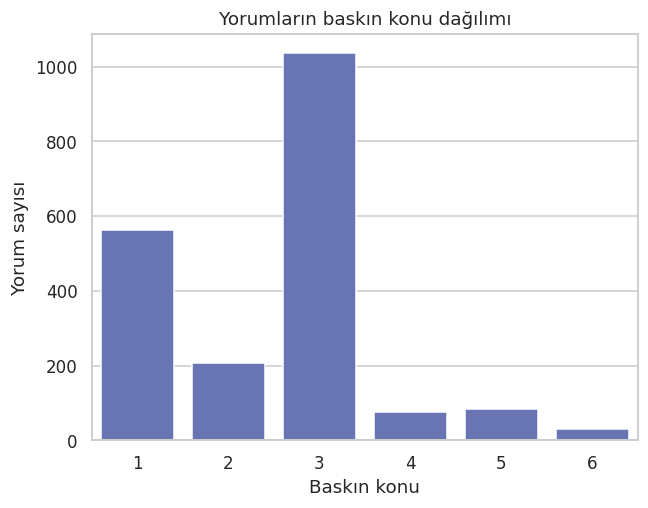

In [5]:
dominant_topic = document_topics.argmax(axis=1)
topic_counts = pd.Series(dominant_topic + 1).value_counts().sort_index()
sns.barplot(x=topic_counts.index, y=topic_counts.values, color="#5C6BC0")
plt.xlabel("Baskın konu"); plt.ylabel("Yorum sayısı"); plt.title("Yorumların baskın konu dağılımı")
plt.show()
joblib.dump({"vectorizer": vectorizer, "nmf": nmf, "topic_terms": topic_terms},
            MODEL_DIR / "12_film_konu_modelleme.joblib")
json.dump({"topic_count": 6, "documents": int(len(df)),
           "reconstruction_error": float(nmf.reconstruction_err_)},
          open(RESULT_DIR / "12_film_konu_modelleme.json", "w"), indent=2)

## Sonuç

Pozitif/negatif etiketleri model eğitimine verilmedi; yalnızca korpusu tanıtmak için gösterildi.
NMF'nin ürettiği konular en yüksek ağırlıklı kelimeler üzerinden insan tarafından adlandırılabilir.
Konu modelleme keşifseldir; bulunan konular kesin sınıflar değildir.

## Kaynak çözümle karşılaştırma

Ödevde verilen proje listelerindeki örnek yaklaşımın odağı **kısa metinlerde konu çıkarımı** biçimindedir.
Bu notebookta **2.000 gerçek ve uzun yorum, metin uzunluğu EDA'sı, 6 konu ve konu yaygınlığı görseli** eklenmiştir. Böylece yalnızca modeli çalıştırmak yerine veri kalitesi,
EDA, görsel kanıt, uygun metrik ve yeniden kullanılabilir model kaydı birlikte sunulmuştur.

Kaynak listeler: [75 Data Science Projects](https://python.plainenglish.io/85-data-science-projects-c03c8750599e)
ve [230 Machine Learning Projects](https://medium.com/coders-camp/230-machine-learning-projects-with-python-5d0c7abf8265).